In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load CSV file
df = pd.read_csv("student_performance_dataset.csv")

# Quick check
print(df.head())
print(df.info())
print(df.columns)

  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                         No   
4                  Masters                      No                        Yes   

   Final_Exam_Score Pass_F

In [3]:
df = df.drop('Student_ID', axis=1)

In [4]:
df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'Parental_Education_Level',
    'Internet_Access_at_Home', 'Extracurricular_Activities'
], drop_first=True)

In [5]:
df_encoded['Pass_Fail'] = df_encoded['Pass_Fail'].map({'Fail': 0, 'Pass': 1})

In [6]:
X = df_encoded.drop('Pass_Fail', axis=1)
y = df_encoded['Pass_Fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

Accuracy: 0.9788732394366197


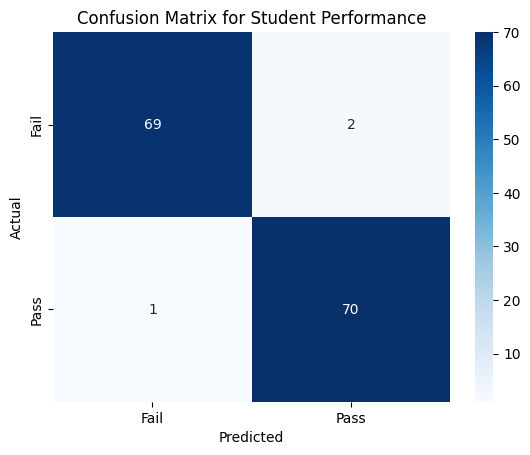

Classification Report:
              precision    recall  f1-score   support

        Fail       0.99      0.97      0.98        71
        Pass       0.97      0.99      0.98        71

    accuracy                           0.98       142
   macro avg       0.98      0.98      0.98       142
weighted avg       0.98      0.98      0.98       142



In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Student Performance")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))